In [1]:
import math
import random
import numpy as np
import mesa
from mesa.space import SingleGrid
import matplotlib.pyplot as plt

In [26]:
class Rietkerk_Model(mesa.Model):
    def __init__(self, n=50, rng=None):
        super().__init__(rng=rng)
        self.grid = SingleGrid(n,n, torus=True)
        self.n = n


        for x in range(n):
            for y in range(n):
                biomass = 3. + random.uniform(0.0, 0.05)
                surface_water = 1. + random.uniform(-0.1, 0.1)
                infiltrated_water = 1. + random.uniform(-0.1, 0.1)
                agente = AgenteSavana(model=self, biomass = biomass, surface_water = surface_water, infiltrated_water = infiltrated_water)
                self.grid.place_agent(agente, (x, y))
    def step(self):
        for agent in self.agents:
            agent.prepare_update()

        for agent in self.agents:
            agent.apply_update()

    def export(self):
        matrix_biomass = np.zeros((self.n, self.n))
        matrix_infiltrated_water = np.zeros((self.n, self.n))
        matrix_surface_water = np.zeros((self.n, self.n))

        for agent, (x, y) in self.grid.coord_iter():
            if agent:
                matrix_biomass[x, y] = agent.biomass
                matrix_infiltrated_water[x, y] = agent.infiltrated_water
                matrix_surface_water[x, y] = agent.surface_water
        return matrix_biomass

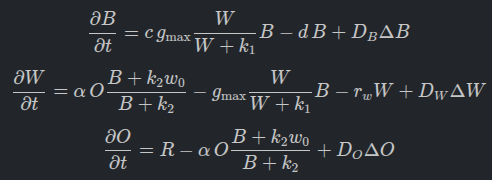

Significado dos Termos e Parâmetros

- $B$ (Biomassa Vegetal).
- $W$ (Água do Solo).
- $O$ (Água de Superfície).
- $\Delta$: Operador Laplaciano, que representa a dispersão e difusão espacial.
- $R$: Taxa de precipitação (chuva), atuando como forçamento externo
- $c \, g_{\max} \frac{W}{W + k_1}B$: Absorção de água pelas raízes e sua conversão em crescimento vegetal.
- $d \, B$: Perda de biomassa devido à mortalidade das plantas.
- $\alpha \, O \frac{B + k_2 w_0}{B + k_2}$: Taxa de infiltração da água de superfície para o solo, a qual é aumentada pela presença da biomassa vegetal.
- $r_w W$: Perda de água do solo por evaporação e drenagem.
- $D_B, D_W, D_O$: Coeficientes de difusão da biomassa vegetal, da água do solo e da água de superfície, respectivamente
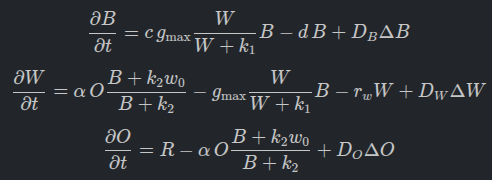
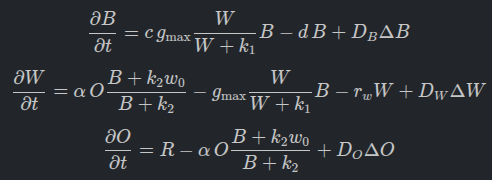

6


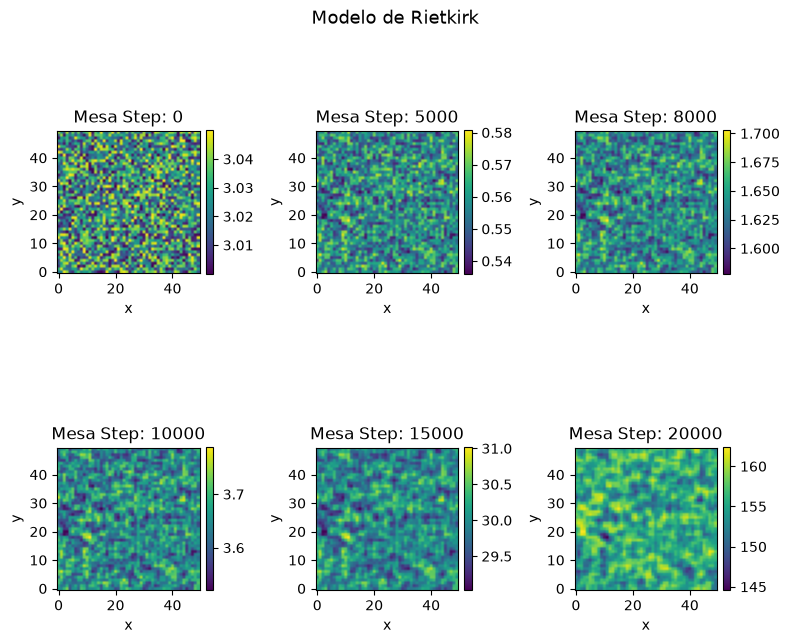

In [32]:
class AgenteSavana(mesa.Agent):
    def __init__(self, model, biomass, surface_water, infiltrated_water):

        # Plant related parameters
        plant_loss_rate = 0.45       # Mortalidade das plantas                            (d)
        plant_water_uptake = 0.1     # Absorsção máxima de agua das raizes             (gMax)
        k1 = 5                       # Constante de meia saturação                       (k1)
        c = 5                        # Coeficiente de conversão da Água                   (c)
        plant_diffusion = 0.01       # Coeficiente de difusão das plantas                (Db)

        # Infiltrated water related parameters
        infiltrated_diffusion = 0.01 # Coeficiente de difusão agua infiltrada            (Dw)
        infiltrated_water_loss = 0.004 # Perda de água do solo por evaporação e drenagem.  (rw)
        alpha = 0.4                  # Taxa máxima de infiltração                      (alpha)
        Wo = 0.2                     # Infiltração no solo Nu
        k2 = 5.0                     # Constante de saturação da infiltração              (k2)

        # surface water related parameters
        rainfall = 3.5               # Chuva (precipitação)                                (R)
        surface_diffusion = 50       # Coeficiente de difusão da agua na superficie       (Do)

        dX = 2

        super().__init__(model)
        self.biomass = biomass
        self.next_biomass = biomass
        self.plant_loss_rate = plant_loss_rate
        self.plant_water_uptake = plant_water_uptake
        self.k1 = k1
        self.c = c
        self.plant_diffusion = plant_diffusion

        self.infiltrated_water = infiltrated_water
        self.next_infiltrated_water = infiltrated_water
        self.infiltrated_diffusion = infiltrated_diffusion
        self.infiltrated_water_loss = infiltrated_water_loss
        self.alpha = alpha
        self.Wo = Wo
        self.k2 = k2

        self.surface_water = surface_water
        self.next_surface_water = surface_water
        self.rainfall = rainfall
        self.surface_diffusion = surface_diffusion

        self.dX = dX
        self.passotempo = 0.01 #0.00025
    def prepare_update(self):
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=False, include_center=False
        )

        Left_Biomass, Right_Biomass, Up_Biomass, Down_Biomass = self.biomass, self.biomass, self.biomass, self.biomass
        Left_Infiltrated_water, Right_Infiltrated_water, Up_Infiltrated_water, Down_Infiltrated_water = self.infiltrated_water, self.infiltrated_water, self.infiltrated_water, self.infiltrated_water
        Left_surface_water, Right_surface_water, Up_surface_water, Down_surface_water = self.surface_water, self.surface_water, self.surface_water, self.surface_water

        x, y = self.pos
        n = self.model.grid.width
        for v in neighbors:
            vx, vy = v.pos
            dx = (vx - x + n) % n
            if dx > n / 2:
                dx -= n
            dy = (vy - y + n) % n
            if dy > n / 2:
                dy -= n

            if dx == -1 and dy == 0:
                Left_Biomass = v.biomass
                Left_Infiltrated_water = v.infiltrated_water
                Left_surface_water = v.surface_water
            elif dx == 1 and dy == 0:
                Right_Biomass = v.biomass
                Right_Infiltrated_water = v.infiltrated_water
                Right_surface_water = v.surface_water
            elif dx == 0 and dy == 1:
                Up_Biomass = v.biomass
                Up_Infiltrated_water = v.infiltrated_water
                Up_surface_water = v.surface_water
            elif dx == 0 and dy == -1:
                Down_Biomass = v.biomass
                Down_Infiltrated_water = v.infiltrated_water
                Down_surface_water = v.surface_water

        biomass_laplacian = ((Left_Biomass + Right_Biomass - 2 * self.biomass) / self.dX / self.dX + (
                    Up_Biomass + Down_Biomass - 2 * self.biomass) / self.dX / self.dX)

        infiltrated_water_laplacian = ((Left_Infiltrated_water + Right_Infiltrated_water - 2 * self.infiltrated_water) / self.dX / self.dX + (
            Up_Infiltrated_water + Down_Infiltrated_water - 2 * self.infiltrated_water) / self.dX / self.dX)

        surface_water_laplacian = ((Left_surface_water + Right_surface_water - 2 * self.surface_water) / self.dX / self.dX + (
            Up_surface_water + Down_surface_water - 2 * self.surface_water) / self.dX / self.dX)

        self.next_biomass = self.biomass + (self.c * self.plant_water_uptake * (self.infiltrated_water / (self.infiltrated_water + self.k1)) * self.biomass - (self.plant_loss_rate * self.biomass) + self.plant_diffusion * biomass_laplacian) * self.passotempo

        self.next_infiltrated_water = self.infiltrated_water + (self.alpha * self.surface_water * ((self.biomass + self.k2 * self.Wo) / (self.biomass + self.k2)) - self.plant_water_uptake * (self.infiltrated_water / (self.infiltrated_water + self.k1)) * self.biomass - self.infiltrated_water_loss * self.infiltrated_water +  self.infiltrated_diffusion * infiltrated_water_laplacian)  * self.passotempo

        self.next_surface_water = self.surface_water + (self.rainfall - self.alpha * self.surface_water * ((self.biomass + self.k2 * self.Wo) / (self.biomass + self.k2)) + self.surface_diffusion * surface_water_laplacian ) * self.passotempo

    def apply_update(self):
        self.biomass = self.next_biomass
        self.infiltrated_water = self.next_infiltrated_water
        self.surface_water = self.next_surface_water


model = Rietkerk_Model(n=50)

steps_to_capture = [0, 5000, 8000, 10000, 15000, 20000]
snapshots = []

for ste in range(20001):
    if ste in steps_to_capture:
        snapshots.append((ste, model.export()))
    model.step()

numShapes = len(snapshots)
cols = 3
rows = math.ceil(numShapes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(8, 7))
axes = axes.flatten()
print(len(snapshots))
for idx, (s, data) in enumerate(snapshots):
    im = axes[idx].imshow(data, cmap='viridis', origin='lower')
    axes[idx].set_title(f'Mesa Step: {s}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Modelo de Rietkirk', fontsize=13)
plt.tight_layout()
plt.show()

np.set_printoptions(precision=1, suppress=True, linewidth=150)